# Sieć dwuwarstwowa — problem XOR

**Cel:** pokazać że sieć neuronowa z warstwą ukrytą potrafi rozwiązać problem
XOR, którego nie można rozwiązać modelem liniowym (np. regresją logistyczną).

**Architektura:** 2 → 4 → 1 (wejście → ukryta ReLU → wyjście Sigmoid)

**Dlaczego XOR jest ważny?**  
XOR nie jest liniowo separowalny — żadna prosta linia nie oddzieli klas 0 i 1.
Warstwa ukryta tworzy nową reprezentację przestrzeni wejściowej w której
problem staje się liniowo separowalny.

| x1 | x2 | XOR |
|----|----|----|
| 0  | 0  | 0  |
| 0  | 1  | 1  |
| 1  | 0  | 1  |
| 1  | 1  | 0  |

## 1. Setup


In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import torch

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams['figure.dpi'] = 100

print("Setup OK")
print(f"PyTorch: {torch.__version__}")

Setup OK
PyTorch: 2.12.0+cpu


## 2. Dataset XOR

XOR ma tylko 4 próbki — trenujemy na całym datasecie (batch_size=4).
Wielokrotne powtarzanie tych samych próbek przez tysiące epok pozwala
sieci "wbić" wzorzec w wagi.

In [2]:
# Wszystkie możliwe wejścia i wyjścia XOR
X_xor = np.array([[0, 0],
                   [0, 1],
                   [1, 0],
                   [1, 1]], dtype=np.float32)

y_xor = np.array([0, 1, 1, 0], dtype=np.float32)

print("Dataset XOR:")
print(f"{'x1':>4} {'x2':>4} {'XOR':>6}")
print("-" * 16)
for (x1, x2), y in zip(X_xor, y_xor):
    print(f"{int(x1):>4} {int(x2):>4} {int(y):>6}")

Dataset XOR:
  x1   x2    XOR
----------------
   0    0      0
   0    1      1
   1    0      1
   1    1      0


## 3. Trenowanie sieci

Architektura: **2 → 4 → 1**
- Warstwa wejściowa: 2 neurony (x1, x2)
- Warstwa ukryta: 4 neurony z aktywacją ReLU
- Wyjście: 1 neuron z aktywacją Sigmoid (prawdopodobieństwo klasy 1)

Mała sieć ucząca się małego datasetu — potrzebuje dużo epok i małego lr
żeby precyzyjnie wbić granicę decyzyjną.

In [ ]:
from utils.models import TwoLayerNetwork

model_xor = TwoLayerNetwork(
    n_input=2,
    n_hidden=4,
    n_output=1,
    lr=0.05,
    mode='binary'
)

history = model_xor.train_network(
    X_xor, y_xor,
    epochs=5000,
    batch_size=4,
    verbose=True
)

Epoch     0/5000 | Loss: 0.744406 | Acc: 0.7500
Epoch   500/5000 | Loss: 0.495948 | Acc: 0.7500
Epoch  1000/5000 | Loss: 0.260847 | Acc: 1.0000
Epoch  1500/5000 | Loss: 0.070827 | Acc: 1.0000
Epoch  2000/5000 | Loss: 0.037445 | Acc: 1.0000
Epoch  2500/5000 | Loss: 0.024739 | Acc: 1.0000
Epoch  3000/5000 | Loss: 0.018227 | Acc: 1.0000
Epoch  3500/5000 | Loss: 0.014338 | Acc: 1.0000
Epoch  4000/5000 | Loss: 0.011760 | Acc: 1.0000
Epoch  4500/5000 | Loss: 0.009943 | Acc: 1.0000


## 4. Weryfikacja predykcji

Sprawdzamy czy sieć poprawnie przewiduje wszystkie 4 kombinacje XOR.
Sieć jest poprawnie nauczona jeśli:
- P(XOR=1) > 0.5 dla (0,1) i (1,0)
- P(XOR=0) < 0.5 dla (0,0) i (1,1)

In [4]:
print("── Predykcje po treningu ──")
print(f"{'x1':>4} {'x2':>4} {'Oczekiwane':>12} {'P(1)':>8} {'Predykcja':>10} {'OK?':>5}")
print("-" * 45)

probs = model_xor.predict_proba(X_xor)
preds = model_xor.predict(X_xor)

all_correct = True
for (x1, x2), y_true, prob, pred in zip(X_xor, y_xor, probs, preds):
    ok = "✓" if int(pred) == int(y_true) else "✗"
    if ok == "✗":
        all_correct = False
    print(f"{int(x1):>4} {int(x2):>4} {int(y_true):>12} {prob:>8.4f} {int(pred):>10} {ok:>5}")

print(f"\n{'✓ Sieć nauczyła się XOR!' if all_correct else '✗ Sieć NIE nauczyła się XOR — spróbuj więcej epok lub innego lr'}")

── Predykcje po treningu ──
  x1   x2   Oczekiwane     P(1)  Predykcja   OK?
---------------------------------------------
   0    0            0   0.0139          0     ✓
   0    1            1   0.9967          1     ✓
   1    0            1   0.9968          1     ✓
   1    1            0   0.0139          0     ✓

✓ Sieć nauczyła się XOR!


## 5. Wykresy uczenia

### Wykres 1: Krzywa straty
Pokazuje jak funkcja straty (Binary Cross-Entropy) spada w trakcie treningu.
Oczekujemy monotonicznego spadku do wartości bliskiej 0.

### Wykres 2: Normy gradientów w warstwach
Norma gradientu `||∂L/∂W||` mówi jak silnie dana warstwa była aktualizowana.
- **Warstwa 2** (bliżej wyjścia) — zwykle ma silniejszy gradient na początku
- **Warstwa 1** (bliżej wejścia) — może mieć słabszy gradient (zanikający gradient)

### Wykres 3: Granica decyzyjna
Wizualizacja co sieć "widzi" w przestrzeni wejściowej — ciemny/jasny kolor
oznacza predykcję klasy 0/1. Punkciki to rzeczywiste dane XOR.

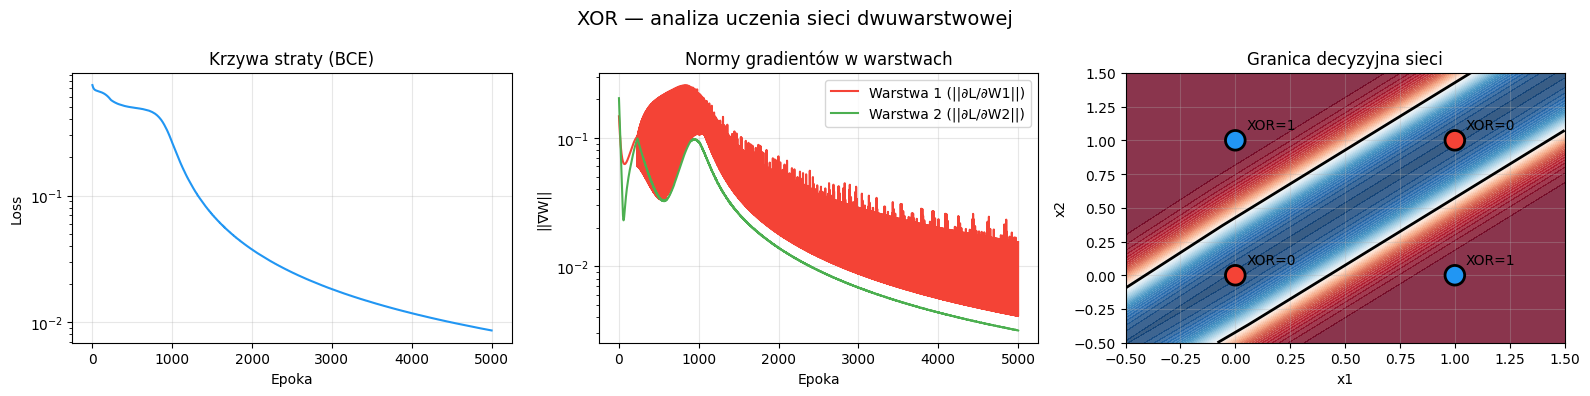

✓ Wykres zapisany do plots/xor_training.png


In [5]:
import os
os.makedirs('../plots', exist_ok=True)

epochs_range = range(1, len(history['loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Wykres 1: Loss ──
axes[0].plot(epochs_range, history['loss'], color='#2196F3', linewidth=1.5)
axes[0].set_title('Krzywa straty (BCE)')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('Loss')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3)

# ── Wykres 2: Gradienty warstw ──
axes[1].plot(epochs_range, history['grad_norm_W1'],
             label='Warstwa 1 (||∂L/∂W1||)', color='#F44336', linewidth=1.5)
axes[1].plot(epochs_range, history['grad_norm_W2'],
             label='Warstwa 2 (||∂L/∂W2||)', color='#4CAF50', linewidth=1.5)
axes[1].set_title('Normy gradientów w warstwach')
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('||∇W||')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── Wykres 3: Granica decyzyjna ──
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200),
                      np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
Z = model_xor.predict_proba(grid).reshape(xx.shape)

axes[2].contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.8)
axes[2].contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
colors = ['#F44336' if y == 0 else '#2196F3' for y in y_xor]
axes[2].scatter(X_xor[:, 0], X_xor[:, 1], c=colors,
                 s=200, edgecolors='black', linewidths=2, zorder=5)

for (x1, x2), y in zip(X_xor, y_xor):
    axes[2].annotate(f'XOR={int(y)}', (x1, x2),
                     textcoords='offset points', xytext=(8, 8), fontsize=10)

axes[2].set_title('Granica decyzyjna sieci')
axes[2].set_xlabel('x1')
axes[2].set_ylabel('x2')
axes[2].grid(alpha=0.3)

plt.suptitle('XOR — analiza uczenia sieci dwuwarstwowej', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/xor_training.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Wykres zapisany do plots/xor_training.png")

## 6. Wnioski

### Przebieg uczenia
Sieć **2 → 4 → 1** poprawnie nauczyła się funkcji XOR po **5000 epokach**
z learning rate `lr=0.05`.

Analiza krzywej straty (wykres 1):
- **Epoka 0:** Loss = 0.7444 — sieć startuje z losowymi wagami, accuracy = 75%
  (przypadkowo przewiduje 3/4 poprawnie)
- **Epoka ~1000:** Loss = 0.2608, accuracy skacze do **100%** — sieć znalazła
  poprawną granicę decyzyjną
- **Epoki 1000–5000:** Loss nadal spada (0.26 → 0.01) mimo że accuracy = 100% —
  sieć "upewnia się" w swoich predykcjach, zwiększając pewność (P(1) zbliża się
  do 0.99, P(0) do 0.01)

### Gradienty w warstwach (wykres 2)
- **Do epoki ~800:** obie warstwy mają rosnące gradienty — sieć aktywnie
  reorganizuje wagi szukając rozwiązania. Widoczny "garb" ok. epoki 500-800
  to moment w którym sieć przeskakuje z lokalnego minimum
- **Po epoce ~1000:** gradienty maleją monotonicznie — sieć konwerguje
- **Warstwa 1 (czerwona) oscyluje** znacznie bardziej niż Warstwa 2 (zielona) —
  warstwa bliżej wejścia dostaje zaszumiony sygnał błędu przechodzący przez W2,
  co powoduje niestabilność gradientu szczególnie na początku uczenia

### Granica decyzyjna (wykres 3)
Sieć wytworzyła **dwie równoległe granice liniowe** tworzące razem kształt
"pasa" — obszar niebieski (XOR=1) to ukośny pas między punktami (0,1) i (1,0),
natomiast narożniki (0,0) i (1,1) pozostają czerwone (XOR=0).

Jest to eleganckie rozwiązanie: warstwa ukryta tworzy dwie granice liniowe,
warstwa wyjściowa łączy je operacją AND — punkt należy do klasy 1 tylko jeśli
jest "między" obiema granicami. Dowodzi to że **XOR wymaga minimum jednej
warstwy ukrytej** — żadna pojedyncza linia nie oddzieliłaby tych klas.

### Predykcje końcowe
Wszystkie 4 kombinacje sklasyfikowane poprawnie z bardzo wysoką pewnością:
P(1) = 0.9967–0.9968 dla klas pozytywnych, P(1) = 0.0139 dla negatywnych.